<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\m'
C:\Users\M.Salah\AppData\Local\Temp\ipykernel_13252\3562325617.py:98: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Expectation $\mu$')
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


Generating harmonic oscillator dataset for MBAR parity...
u_kn shape: (3, 1500)
N_k       : [500 500 500]

          RUNNING REFERENCE FRAMEWORK (pymbar)
-> Reference MBAR expectations finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy MBAR expectations finished.

          PARITY VALIDATION
1. MSE on Expectations (mu)           : 0.000000e+00
2. MSE on Expectations (sigma)        : 0.000000e+00

Plot saved to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_mbar\verify_parity_mbar_expectations_plot.png

SUCCESS: DimRedPy MBAR Expectations perfectly match pymbar reference.


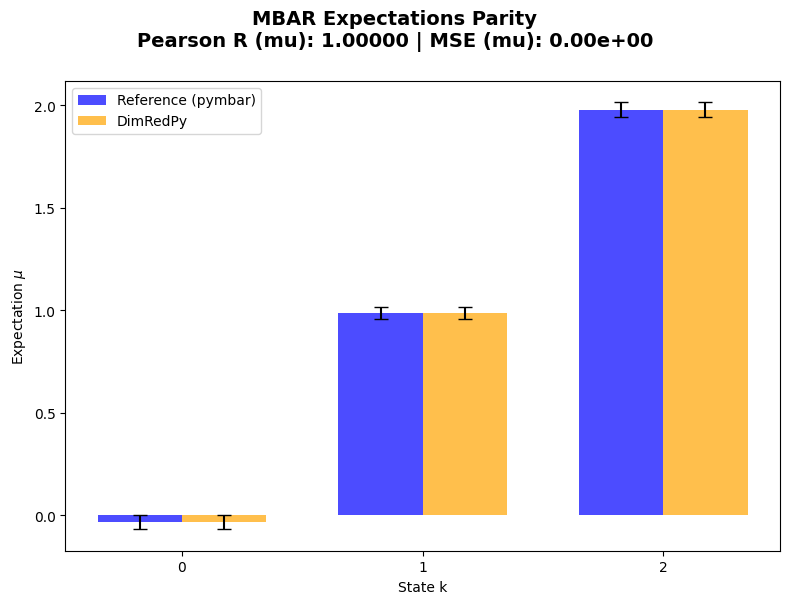

In [1]:
"""
Rigorous Verification of MBAR Parity: Expectations
"""

import numpy as np
import os
import sys

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from pymbar import MBAR
from pymbar.testsystems import HarmonicOscillatorsTestCase
from dimredpy.mbar import run_mbar, mbar_compute_expectations

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating harmonic oscillator dataset for MBAR parity...")
testcase = HarmonicOscillatorsTestCase(O_k=[0, 1, 2], K_k=[1, 1, 1])
x_n, u_kn, N_k, s_n = testcase.sample(N_k=[500, 500, 500])

print(f"u_kn shape: {u_kn.shape}")
print(f"N_k       : {N_k}")

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (pymbar)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (pymbar)")
print("=======================================================")

mbar_ref = MBAR(u_kn, N_k, solver_protocol="default")

# Expectations (Observable: positions x_n)
ref_exp = mbar_ref.compute_expectations(x_n, compute_uncertainty=True)
if isinstance(ref_exp, dict):
    ref_mu = ref_exp["mu"]
    ref_sigma = ref_exp["sigma"]
else:
    ref_mu = ref_exp[0]
    ref_sigma = ref_exp[1]

print("-> Reference MBAR expectations finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

res_dimredpy = run_mbar(u_kn, N_k, solver="default")

exp_dimredpy = mbar_compute_expectations(res_dimredpy, x_n, state_dependent=False, compute_uncertainty=True)
dimredpy_mu = exp_dimredpy["mu"]
dimredpy_sigma = exp_dimredpy["sigma"]

print("-> DimRedPy MBAR expectations finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse_mu = np.mean((ref_mu - dimredpy_mu) ** 2)
mse_sigma = np.mean((ref_sigma - dimredpy_sigma) ** 2)

print(f"1. MSE on Expectations (mu)           : {mse_mu:.6e}")
print(f"2. MSE on Expectations (sigma)        : {mse_sigma:.6e}")

total_mse = mse_mu + mse_sigma

# ---------------------------------------------------------------------------
# 5. Plotting Parity
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

r_val_mu, _ = pearsonr(ref_mu, dimredpy_mu)

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f"MBAR Expectations Parity\nPearson R (mu): {r_val_mu:.5f} | MSE (mu): {mse_mu:.2e}", 
             fontsize=14, fontweight='bold', y=1.00)

states = np.arange(len(ref_mu))
width = 0.35

ax.bar(states - width/2, ref_mu, width, yerr=ref_sigma, label='Reference (pymbar)', capsize=5, color='blue', alpha=0.7)
ax.bar(states + width/2, dimredpy_mu, width, yerr=dimredpy_sigma, label='DimRedPy', capsize=5, color='orange', alpha=0.7)

ax.set_xlabel('State k')
ax.set_ylabel('Expectation $\mu$')
ax.set_xticks(states)
ax.legend()

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_mbar_expectations_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to {plot_path}")

if total_mse < 1e-10:
    print("\nSUCCESS: DimRedPy MBAR Expectations perfectly match pymbar reference.")
else:
    print("\nFAILURE: Statistical divergence detected in MBAR parity.")

